# Correlation

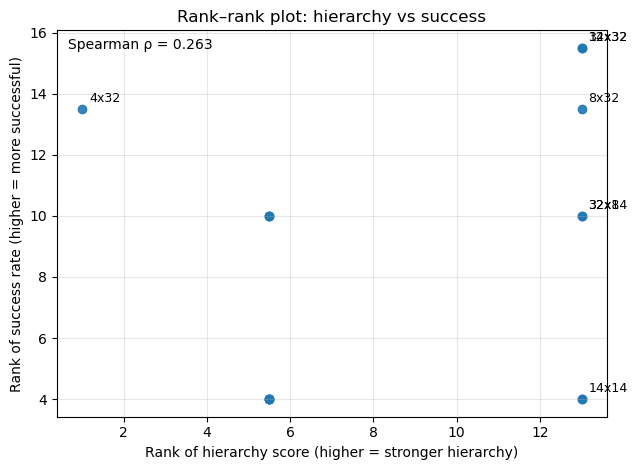

df[success_rate] 0     0.3
1     0.7
2     0.4
3     0.3
4     0.4
5     0.7
6     0.4
7     0.4
8     0.3
9     0.6
10    0.3
11    0.3
12    0.3
13    0.6
14    0.4
15    0.3
Name: success_rate, dtype: float64
df[hierarchy_score] 0     0.95
1     0.95
2     0.50
3     0.95
4     0.95
5     0.95
6     0.50
7     0.95
8     0.50
9     0.10
10    0.50
11    0.50
12    0.50
13    0.95
14    0.50
15    0.50
Name: hierarchy_score, dtype: float64
df[high_success] 0     0
1     1
2     0
3     0
4     0
5     1
6     0
7     0
8     0
9     1
10    0
11    0
12    0
13    1
14    0
15    0
Name: high_success, dtype: int64
df[high_hierarchy] 0     1
1     1
2     0
3     1
4     1
5     1
6     0
7     1
8     0
9     0
10    0
11    0
12    0
13    1
14    0
15    0
Name: high_hierarchy, dtype: int64
Binary association summary (thresholded)
  Success threshold   : 0.6
  Hierarchy threshold : 0.85

Counts:
                 Success: High  Success: Low
Hierarchy: High              3            

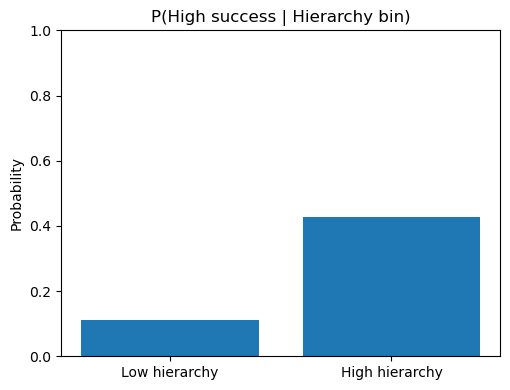

Saved figures:
 - Rank–rank plot: plots/rank_rank_hierarchy_vs_success.png
 - Conditional probability bars: conditional_success_given_hierarchy.png
 - Top-K overlap curve: plots/topk_overlap_hierarchy_success.png


In [9]:
# %%
# Implementation of (1) rank–rank plot, (2) binary association,
# and (4) top-K overlap for hierarchy vs success.
#
# Notes:
# - Success rates are hardcoded from the provided level_2 matrix.
# - We exclude all pairs that involve 1.7B (per user request).
# - "Hierarchy score" is expected to come from your CLEAR-hierarchy metric.
#
# ──────────────────────────────────────────────────────────────────────────────

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ------------------------------
# 0) Parameters
# ------------------------------

SUCCESS_THRESHOLD = 0.60  # define "High success"
HIERARCHY_THRESHOLD = 0.85  # define "High hierarchy" (edit as you see fit)

# Models to include (1.7B excluded)
models = ["Qwen3-4B", "Qwen3-8B", "Qwen3-14B", "Qwen3-32B"]

# Hardcoded success-rate matrix from screenshot; rows=source, cols=target.
# Full 5x5 (1.7B, 4B, 8B, 14B, 32B) for context:
# success_full = np.array([
#     [0.0, 0.5, 0.6, 0.7, 0.7],  # 1.7B
#     [0.1, 0.3, 0.3, 0.3, 0.6],  # 4B
#     [0.1, 0.4, 0.3, 0.3, 0.6],  # 8B
#     [0.1, 0.4, 0.3, 0.3, 0.7],  # 14B
#     [0.1, 0.4, 0.4, 0.4, 0.7],  # 32B
# ], dtype=float)

# Extract the 4x4 submatrix excluding 1.7B (order: 4B, 8B, 14B, 32B)
success_sub = np.array([
    [0.3, 0.3, 0.3, 0.6],  # 4B → (4B, 8B, 14B, 32B)
    [0.4, 0.3, 0.3, 0.6],  # 8B →
    [0.4, 0.3, 0.3, 0.7],  # 14B →
    [0.4, 0.4, 0.4, 0.7],  # 32B →
], dtype=float)

# Convenience mapping from model string to a short token used in labels/keys
def short(m):
    # "Qwen3-14B" -> "14"; "Qwen3-32B" -> "32"
    return m.split("-")[1].replace("B", "")

def pair_key(src, tgt):
    return f"{short(src)}x{short(tgt)}"

# ------------------------------
# 1) Build the oriented pair dataset
# ------------------------------

records = []
for i, src in enumerate(models):
    for j, tgt in enumerate(models):
        key = pair_key(src, tgt)
        records.append({
            "source": src,
            "target": tgt,
            "pair": key,
            "success_rate": float(success_sub[i, j]),
        })
df = pd.DataFrame.from_records(records)

# ------------------------------
# 2) Load/define hierarchy scores
# ------------------------------

def maybe_load_hierarchy_from_csv(path="sym_GPT5_data.csv"):
    if not os.path.exists(path):
        return None
    try:
        tmp = pd.read_csv(path)
        cols = [c.lower() for c in tmp.columns]
        # Expect at least source, target, and hierarchy_score columns
        need = {"source", "target", "hierarchy_score"}
        lc_map = {c.lower(): c for c in tmp.columns}
        if need.issubset(set(cols)):
            src_col = lc_map["source"]
            tgt_col = lc_map["target"]
            hs_col  = lc_map["hierarchy_score"]
            sub = tmp[[src_col, tgt_col, hs_col]].copy()
            sub.columns = ["source", "target", "hierarchy_score"]
            # Only keep rows whose models are in our list and create pair key
            sub = sub[sub["source"].isin(models) & sub["target"].isin(models)].copy()
            sub["pair"] = sub.apply(lambda r: pair_key(r["source"], r["target"]), axis=1)
            return sub[["pair", "hierarchy_score"]]
        else:
            return None
    except Exception as e:
        # If the CSV is not in the expected format, ignore silently.
        return None

hier_from_csv = maybe_load_hierarchy_from_csv()

if hier_from_csv is None:
    # Fallback: assign illustrative hierarchy scores.
    # High-hierarchy pairs from your note:
    high_pairs = {
        "14x14", "14x32", "14x8", "32x14", "32x8", "8x32", "32x32"
    }
    # Known "fades/inverts" case:
    low_pairs = {"4x32"}

    # Default baseline for others
    default_score = 0.50

    hierarchy_scores = {}
    for _, r in df.iterrows():
        pk = r["pair"]
        if pk in high_pairs:
            # strongly clear/consistent
            hierarchy_scores[pk] = 0.95
        elif pk in low_pairs:
            # unstable/inverted
            hierarchy_scores[pk] = 0.10
        else:
            hierarchy_scores[pk] = default_score

    hier_df = pd.DataFrame({
        "pair": list(hierarchy_scores.keys()),
        "hierarchy_score": list(hierarchy_scores.values())
    })

else:
    hier_df = hier_from_csv.copy()

# Merge into main df
df = df.merge(hier_df, on="pair", how="left")

# Guard: if any hierarchy_score is missing, fill with neutral 0.5 (so figures still render)
df["hierarchy_score"] = df["hierarchy_score"].fillna(0.50)

# For reproducibility, order the pairs consistently
df.sort_values(["source", "target"], inplace=True, ignore_index=True)

# Show the base table to the user

# ------------------------------
# 3) (1) Rank–rank plot
# ------------------------------

# Compute ranks (1 = lowest, N = highest). Ties get average rank.
df["rank_hierarchy"] = df["hierarchy_score"].rank(method="average")
df["rank_success"]   = df["success_rate"].rank(method="average")

# Spearman correlation (equivalent to Pearson on ranks)
spearman = df["rank_hierarchy"].corr(df["rank_success"], method="pearson")

# Create scatter
plt.figure(figsize=(6.5, 4.8))
plt.scatter(df["rank_hierarchy"], df["rank_success"], alpha=0.9)
for _, r in df.iterrows():
    # Label a few notable points to aid interpretation
    if r["pair"] in {"4x32", "14x32", "32x32", "14x14", "32x14", "32x8", "8x32"}:
        plt.annotate(r["pair"], (r["rank_hierarchy"], r["rank_success"]), xytext=(5, 5),
                     textcoords="offset points", fontsize=9)
plt.title("Rank–rank plot: hierarchy vs success")
plt.xlabel("Rank of hierarchy score (higher = stronger hierarchy)")
plt.ylabel("Rank of success rate (higher = more successful)")
plt.grid(True, alpha=0.3)
plt.text(0.02, 0.98, f"Spearman ρ = {spearman:.3f}", transform=plt.gca().transAxes,
         ha="left", va="top")
plt.tight_layout()
rank_rank_path = "plots/rank_rank_hierarchy_vs_success.png"
plt.savefig(rank_rank_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------
# 4) (2) Binary association: confusion matrix + effect sizes
# ------------------------------


print('df[success_rate]', df["success_rate"])
print('df[hierarchy_score]', df["hierarchy_score"])

df["high_success"]   = (df["success_rate"] >= SUCCESS_THRESHOLD).astype(int)
df["high_hierarchy"] = (df["hierarchy_score"] >= HIERARCHY_THRESHOLD).astype(int)


print('df[high_success]', df["high_success"])
print('df[high_hierarchy]', df["high_hierarchy"])

TP = int(((df["high_hierarchy"] == 1) & (df["high_success"] == 1)).sum())
FP = int(((df["high_hierarchy"] == 1) & (df["high_success"] == 0)).sum())
FN = int(((df["high_hierarchy"] == 0) & (df["high_success"] == 1)).sum())
TN = int(((df["high_hierarchy"] == 0) & (df["high_success"] == 0)).sum())

# Confusion matrix as a DataFrame
cm = pd.DataFrame(
    [[TP, FP],
     [FN, TN]],
    index=["Hierarchy: High", "Hierarchy: Low"],
    columns=["Success: High", "Success: Low"]
)

# Odds ratio (Haldane-Anscombe correction if any zero cells)
a, b, c, d = TP, FP, FN, TN
if 0 in [a, b, c, d]:
    a += 0.5; b += 0.5; c += 0.5; d += 0.5
odds_ratio = (a * d) / (b * c)

# Fisher exact p-value (if SciPy available)
p_value = None
try:
    from scipy.stats import fisher_exact
    _, p_value = fisher_exact([[TP, FP], [FN, TN]], alternative="greater")
except Exception:
    p_value = None

# Matthews correlation coefficient (MCC)
den = math.sqrt((TP + FP) * (TP + FN) * (TN + FP) * (TN + FN))
mcc = ((TP * TN) - (FP * FN)) / den if den > 0 else float("nan")

# Print a concise summary
print("Binary association summary (thresholded)")
print(f"  Success threshold   : {SUCCESS_THRESHOLD}")
print(f"  Hierarchy threshold : {HIERARCHY_THRESHOLD}")
print("\nCounts:")
print(cm.to_string())
print("\nEffect sizes:")
print(f"  Odds ratio (H vs ¬H on High Success): {odds_ratio:.3f}")
if p_value is not None:
    print(f"  Fisher's exact p-value (one-sided, greater): {p_value:.4g}")
else:
    print("  Fisher's exact p-value: (SciPy not available)")
print(f"  Matthews corr. coeff. (MCC)         : {mcc:.3f}")

# For visualization, show conditional probabilities
grouped = df.groupby("high_hierarchy")["high_success"].mean().rename({0: "Low", 1: "High"})
plt.figure(figsize=(5.2, 4.0))
plt.bar(["Low hierarchy", "High hierarchy"],
        [grouped.loc["Low"] if "Low" in grouped.index else 0.0,
         grouped.loc["High"] if "High" in grouped.index else 0.0])
plt.title("P(High success | Hierarchy bin)")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.tight_layout()
condprob_path = "conditional_success_given_hierarchy.png"
plt.savefig(condprob_path, dpi=200, bbox_inches="tight")
plt.show()

# ------------------------------
# 5) (4) Top-K overlap curve
# ------------------------------
#this seems just wrong?
# # Rank by hierarchy score and by success rate (descending)
# ranked_hier = df.sort_values("hierarchy_score", ascending=False).reset_index(drop=True)
# ranked_succ = df.sort_values("success_rate", ascending=False).reset_index(drop=True)

# N = len(df)
# Ks = np.arange(1, N + 1, dtype=int)
# overlap_frac = []
# for K in Ks:
#     set_h = set(ranked_hier.loc[:K-1, "pair"].tolist())
#     set_s = set(ranked_succ.loc[:K-1, "pair"].tolist())
#     inter = len(set_h.intersection(set_s))
#     overlap_frac.append(inter / K)

# plt.figure(figsize=(6.2, 4.2))
# plt.plot(Ks, overlap_frac, marker="o")
# plt.title("Top-K overlap between hierarchy-top and success-top pairs")
# plt.xlabel("K")
# plt.ylabel("Overlap fraction (|TopK_hier ∩ TopK_succ| / K)")
# plt.ylim(0, 1.05)
# plt.grid(True, alpha=0.3)
# plt.tight_layout()
# topk_path = "plots/topk_overlap_hierarchy_success.png"
# plt.savefig(topk_path, dpi=200, bbox_inches="tight")
# plt.show()

print("Saved figures:")
print(" - Rank–rank plot:", rank_rank_path)
print(" - Conditional probability bars:", condprob_path)
print(" - Top-K overlap curve:", topk_path)


For fixed rates of success and hierarchy we have the above plots

SUCCESS_THRESHOLD = 0.60  # define "High success"

HIERARCHY_THRESHOLD = 0.85  # define "High hierarchy" (edit as you see fit)
